## Powering the Energiewende
## Analysis & Forecasting of Germany's Electricity Demand and Renewable Generation (2006–2017)

**Author:** Hitik Sharma
**Data source:** [Open Power System Data (OPSD)](https://open-power-system-data.org/) (https://github.com/jenfly/opsd) —  a platform for open data of the European power system, used by energy modelers and analysts in academia and industry.

---

### Project summary
Germany's *Energiewende* (energy transition) is one of the most ambitious decarbonization programs in the world. This project analyzes **12 years of daily German electricity data** to (1) quantify how wind and solar reshaped the national grid, (2) uncover the demand patterns that drive the power system, and (3) build machine-learning models that **forecast daily electricity demand with under 2% error**.

This combines **Data Analytics** (deep exploratory analysis + insight extraction) and **Data Science** (feature engineering + predictive modeling + evaluation) into one end-to-end pipeline.

### Why this matters
Accurate demand forecasting is the backbone of a reliable, renewable-heavy grid. Grid operators (e.g. the four German TSOs — 50Hertz, Amprion, TenneT, TransnetBW), utilities, and energy traders rely on it to balance supply and demand, schedule generation, and integrate variable renewables without blackouts or curtailment.

### Table of contents
1. Setup & data loading
2. Data understanding
3. Feature engineering
4. Exploratory Data Analysis (8 analyses)
5. Key insights
6. Predictive modeling — demand forecasting
7. Model evaluation & interpretation
8. Conclusions & business recommendations
9. Future work


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110

# Consistent, colorblind-friendly palette used throughout
C_DEMAND, C_WIND, C_SOLAR = '#2b2d42', '#118ab2', '#ffb703'
C_ACCENT, C_GREEN = '#e63946', '#06d6a0'
print('Libraries loaded.')

Libraries loaded.


In [4]:
# The OPSD Germany daily dataset: national electricity consumption + wind & solar generation
df = pd.read_csv('opsd_germany_daily.csv', parse_dates=['Date'])
df = df.sort_values('Date').set_index('Date')
print(f'Dataset shape: {df.shape[0]:,} daily records × {df.shape[1]} columns')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()} '
      f'({(df.index.max()-df.index.min()).days/365.25:.0f} years)')
df.head()

Dataset shape: 4,383 daily records × 4 columns
Date range: 2006-01-01 to 2017-12-31 (12 years)


,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,1069.184,NaN,NaN,NaN
2006-01-02,1380.521,NaN,NaN,NaN
2006-01-03,1442.533,NaN,NaN,NaN
2006-01-04,1457.217,NaN,NaN,NaN
2006-01-05,1477.131,NaN,NaN,NaN


## 2. Data Understanding

All three measures are in **GWh (gigawatt-hours)**:
- **Consumption** — total national electricity demand
- **Wind** — total wind power generation
- **Solar** — total solar (PV) generation
- **Wind+Solar** — combined renewable generation

A quick look at data types, ranges, and missing values.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4383 entries, 2006-01-01 to 2017-12-31
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Consumption  4383 non-null   float64
 1   Wind         2920 non-null   float64
 2   Solar        2188 non-null   float64
 3   Wind+Solar   2187 non-null   float64
dtypes: float64(4)
memory usage: 171.2 KB


In [6]:
df.describe().round(1)

,Consumption,Wind,Solar,Wind+Solar
count,4383.0,2920.0,2188.0,2187.0
mean,1338.7,164.8,89.3,272.7
std,165.8,143.7,58.6,146.3
min,842.4,5.8,2.0,21.5
25%,1217.9,62.4,35.2,172.2
50%,1367.1,119.1,86.4,241.0
75%,1457.8,217.9,135.1,339.0
max,1709.6,826.3,241.6,851.6


In [7]:
# Missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nFirst wind reading:  {df[df.Wind.notna()].index.min().date()}')
print(f'First solar reading: {df[df.Solar.notna()].index.min().date()}')

Missing values per column:
Consumption       0
Wind           1463
Solar          2195
Wind+Solar     2196
dtype: int64

First wind reading:  2010-01-01
First solar reading: 2012-01-01


**Important data-understanding note.** The missing wind and solar values are **not random gaps** — they mark when Germany began systematically reporting each source: **wind from 2010, solar from 2012**. Consumption is complete across all 12 years. This is itself part of the Energiewende story: these energy sources were negligible before and only became grid-relevant enough to track in the 2010s. We therefore treat pre-2010 wind and pre-2012 solar as *"not yet collected"* rather than imputing them, and we build our demand-forecasting model on the complete consumption series using calendar and lag features.

## 3. Feature Engineering

Time series forecasting lives and dies by good features. We engineer three families:
- **Calendar features** — year, month, day-of-week, day-of-year, quarter, weekend flag, season
- **Renewable features** — combined renewable generation and its share of demand
- *(Lag & rolling features are added later, specifically for the modeling stage)*

In [8]:
d = df.copy()
d['Year']=d.index.year; d['Month']=d.index.month; d['Day']=d.index.day
d['DayOfWeek']=d.index.dayofweek; d['DayOfYear']=d.index.dayofyear
d['WeekOfYear']=d.index.isocalendar().week.astype(int); d['Quarter']=d.index.quarter
d['IsWeekend']=(d.DayOfWeek>=5).astype(int)
season_map={12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
            6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'}
d['Season']=d.Month.map(season_map)
d['RenewTotal']=d[['Wind','Solar']].sum(axis=1,min_count=1)
d['RenewShare']=(d.RenewTotal/d.Consumption*100)
print('Engineered features:', [c for c in d.columns if c not in df.columns])
d[['Consumption','Wind','Solar','Year','Month','DayOfWeek','Season','RenewShare']].head()

Engineered features: ['Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'WeekOfYear', 'Quarter', 'IsWeekend', 'Season', 'RenewTotal', 'RenewShare']


,Consumption,Wind,Solar,Year,Month,DayOfWeek,Season,RenewShare
Date,,,,,,,,
2006-01-01,1069.184,NaN,NaN,2006,1,6,Winter,NaN
2006-01-02,1380.521,NaN,NaN,2006,1,0,Winter,NaN
2006-01-03,1442.533,NaN,NaN,2006,1,1,Winter,NaN
2006-01-04,1457.217,NaN,NaN,2006,1,2,Winter,NaN
2006-01-05,1477.131,NaN,NaN,2006,1,3,Winter,NaN


## 4. Exploratory Data Analysis



### 4.1 — How has national demand evolved over 12 years?

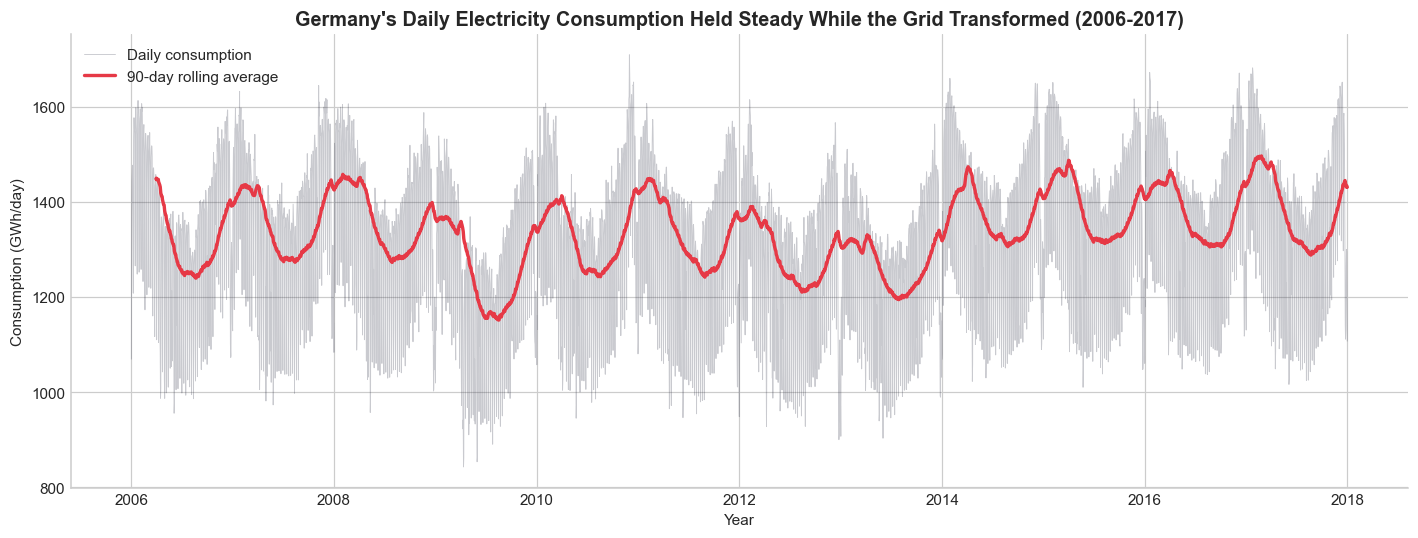

In [9]:
fig,ax=plt.subplots(figsize=(13,5))
ax.plot(d.index,d.Consumption,color=C_DEMAND,alpha=0.25,lw=0.6,label='Daily consumption')
ax.plot(d.index,d.Consumption.rolling(90).mean(),color=C_ACCENT,lw=2.2,label='90-day rolling average')
ax.set_title("Germany's Daily Electricity Consumption Held Steady While the Grid Transformed (2006-2017)",
             fontsize=13,fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Consumption (GWh/day)')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

**Insight.** Total demand is remarkably **stable** (~1,340 GWh/day on average), with a visible dip during the 2009 financial crisis and strong, repeating annual waves. Efficiency gains roughly offset economic and population growth — so the real transformation of this period was on the **supply** side, not the demand side.

### 4.2 — The Energiewende: how fast did renewables grow?

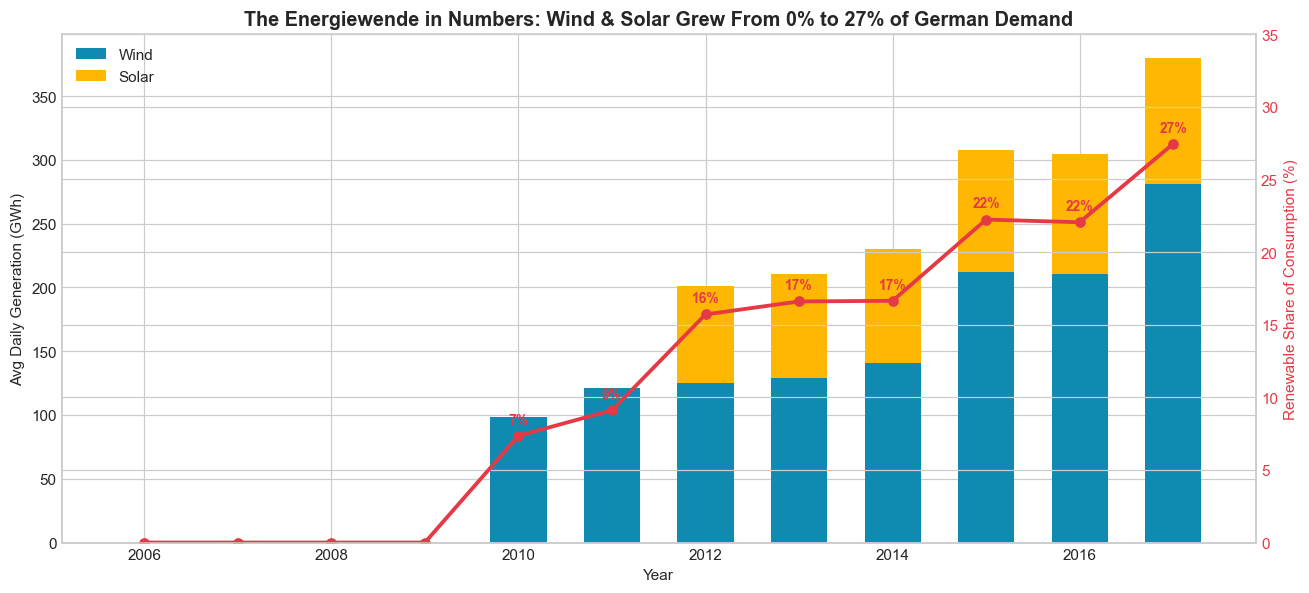

,Consumption,Wind,Solar,RenewShare
Year,,,,
2006,1339.9,NaN,NaN,0.000000
2007,1360.6,NaN,NaN,0.000000
2008,1354.0,NaN,NaN,0.000000
2009,1259.6,NaN,NaN,0.000000
2010,1338.6,98.4,NaN,7.350964
2011,1328.3,121.0,NaN,9.109388
2012,1283.0,125.3,76.2,15.705378
2013,1269.4,129.3,81.4,16.598393
2014,1381.3,140.4,89.5,16.643741


In [10]:
yearly=d.groupby('Year').agg(Consumption=('Consumption','mean'),Wind=('Wind','mean'),
                             Solar=('Solar','mean')).round(1)
yearly['RenewShare']=((yearly.Wind.fillna(0)+yearly.Solar.fillna(0))/yearly.Consumption*100)

fig,ax=plt.subplots(figsize=(12,5.5))
yrs=yearly.index
ax.bar(yrs,yearly.Wind.fillna(0),color=C_WIND,label='Wind',width=0.6)
ax.bar(yrs,yearly.Solar.fillna(0),bottom=yearly.Wind.fillna(0),color=C_SOLAR,label='Solar',width=0.6)
ax.set_ylabel('Avg Daily Generation (GWh)'); ax.set_xlabel('Year')
ax2=ax.twinx()
ax2.plot(yrs,yearly.RenewShare,color=C_ACCENT,marker='o',lw=2.5)
ax2.set_ylabel('Renewable Share of Consumption (%)',color=C_ACCENT)
ax2.tick_params(axis='y',labelcolor=C_ACCENT); ax2.set_ylim(0,35)
for x,v in zip(yrs,yearly.RenewShare):
    if v>0: ax2.annotate(f'{v:.0f}%',(x,v),textcoords='offset points',xytext=(0,8),
                         ha='center',color=C_ACCENT,fontweight='bold',fontsize=9)
ax.set_title("The Energiewende in Numbers: Wind & Solar Grew From 0% to 27% of German Demand",
             fontsize=13,fontweight='bold')
ax.legend(loc='upper left',frameon=False); ax.spines[['top']].set_visible(False)
plt.tight_layout(); plt.show()
display(yearly)

**Insight.** This is the headline story. Renewable penetration climbed from **effectively 0% in 2006 to 27.5% by 2017** — wind roughly tripled and solar went from nothing to a stable contributor. By the end of the period, **more than a quarter of German electricity demand was met by wind and solar alone** (before even counting hydro and biomass). This is exactly the volatility that makes accurate demand forecasting mission-critical.

### 4.3 — When during the year is demand highest?

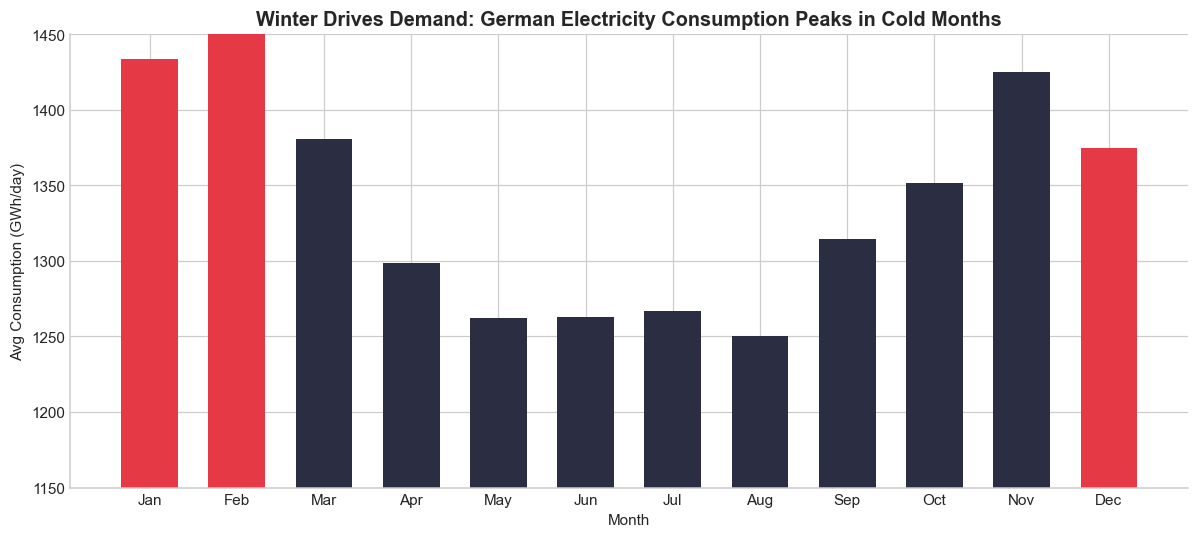

In [11]:
monthly=d.groupby('Month').Consumption.mean()
fig,ax=plt.subplots(figsize=(11,5))
colors=[C_ACCENT if m in [12,1,2] else C_DEMAND for m in monthly.index]
ax.bar(monthly.index,monthly.values,color=colors,width=0.65)
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title("Winter Drives Demand: German Electricity Consumption Peaks in Cold Months",
             fontsize=13,fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Avg Consumption (GWh/day)')
ax.set_ylim(1150,1450); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

**Insight.** Demand is clearly **seasonal**, peaking in **winter** (heating, lighting, shorter days) and bottoming in **summer**. The gap between the highest and lowest months is roughly **15%** — a large, predictable swing that any forecasting model must capture.

### 4.4 — Do weekdays and weekends differ?

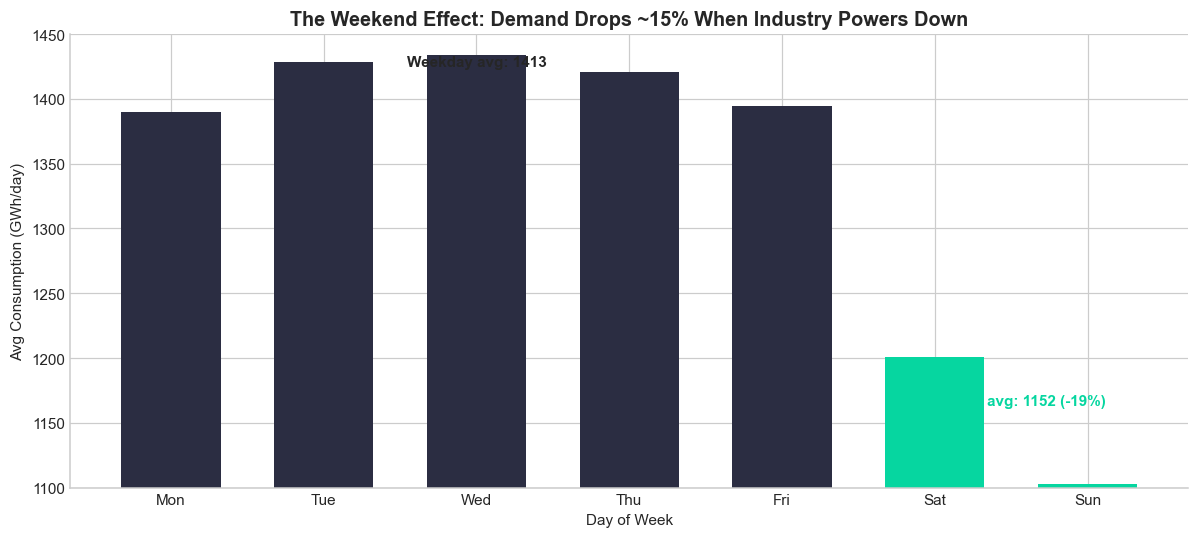

In [12]:
dow=d.groupby('DayOfWeek').Consumption.mean()
fig,ax=plt.subplots(figsize=(11,5))
colors=[C_DEMAND]*5+[C_GREEN]*2
ax.bar(range(7),dow.values,color=colors,width=0.65)
ax.set_xticks(range(7)); ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
wd=dow[:5].mean(); we=dow[5:].mean()
ax.set_title("The Weekend Effect: Demand Drops ~15% When Industry Powers Down",
             fontsize=13,fontweight='bold')
ax.set_xlabel('Day of Week'); ax.set_ylabel('Avg Consumption (GWh/day)')
ax.set_ylim(1100,1450); ax.spines[['top','right']].set_visible(False)
ax.annotate(f'Weekday avg: {wd:.0f}',(2,wd),textcoords='offset points',xytext=(0,10),ha='center',fontweight='bold')
ax.annotate(f'Weekend avg: {we:.0f} (-{(wd-we)/wd*100:.0f}%)',(5.5,we),textcoords='offset points',
            xytext=(0,10),ha='center',fontweight='bold',color=C_GREEN)
plt.tight_layout(); plt.show()

**Insight.** Industrial and commercial activity dominates German demand: weekends run about **15% below** weekdays. This weekly cycle is one of the strongest, most learnable signals in the data — which is why day-of-week features and 7-day lags will prove so powerful in the model.

### 4.5 — Do wind and solar complement each other?

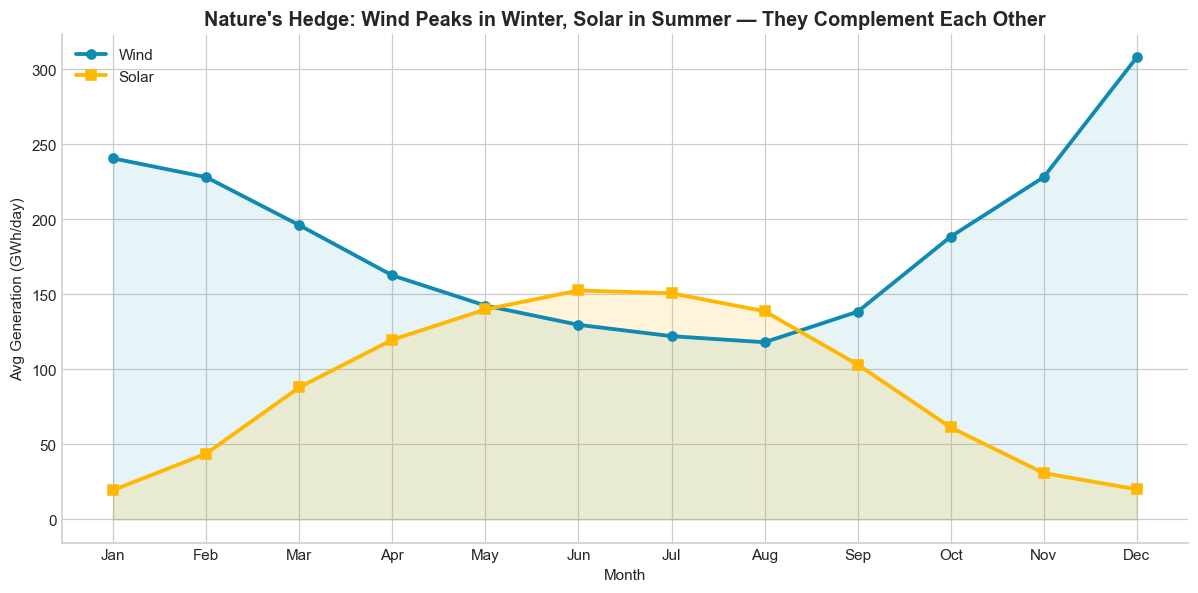

In [13]:
ws=d[d.Solar.notna()].groupby('Month')[['Wind','Solar']].mean()
fig,ax=plt.subplots(figsize=(11,5.5))
ax.plot(ws.index,ws.Wind,color=C_WIND,marker='o',lw=2.5,label='Wind')
ax.plot(ws.index,ws.Solar,color=C_SOLAR,marker='s',lw=2.5,label='Solar')
ax.fill_between(ws.index,ws.Wind,alpha=0.1,color=C_WIND)
ax.fill_between(ws.index,ws.Solar,alpha=0.15,color=C_SOLAR)
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title("Nature's Hedge: Wind Peaks in Winter, Solar in Summer — They Complement Each Other",
             fontsize=13,fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Avg Generation (GWh/day)')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

**Insight.** A crucial finding for grid planning: **wind generation peaks in winter, solar in summer.** The two renewables are naturally *anti-correlated* across the year, partially hedging each other. This seasonal complementarity is precisely why Germany invested in **both** technologies rather than betting on one — together they smooth the annual renewable supply curve.

### 4.6 — What does the demand distribution look like?

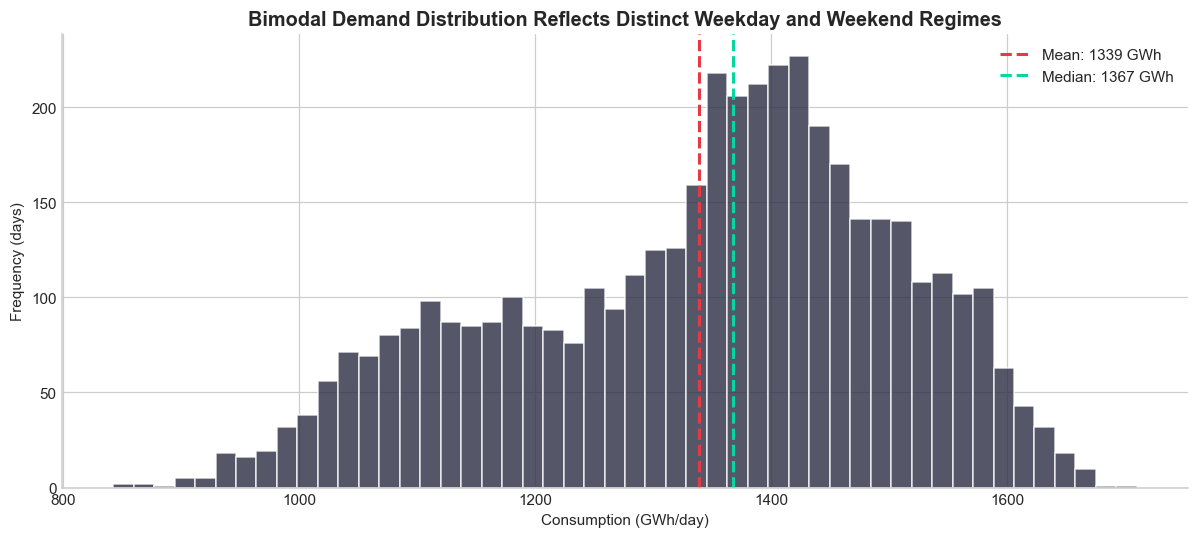

In [14]:
fig,ax=plt.subplots(figsize=(11,5))
ax.hist(d.Consumption,bins=50,color=C_DEMAND,alpha=0.8,edgecolor='white')
ax.axvline(d.Consumption.mean(),color=C_ACCENT,lw=2,ls='--',label=f'Mean: {d.Consumption.mean():.0f} GWh')
ax.axvline(d.Consumption.median(),color=C_GREEN,lw=2,ls='--',label=f'Median: {d.Consumption.median():.0f} GWh')
ax.set_title("Bimodal Demand Distribution Reflects Distinct Weekday and Weekend Regimes",
             fontsize=13,fontweight='bold')
ax.set_xlabel('Consumption (GWh/day)'); ax.set_ylabel('Frequency (days)')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

**Insight.** The distribution is **bimodal** — two humps corresponding to the weekday regime (higher) and the weekend regime (lower). This confirms statistically what section 4.4 showed: German demand effectively operates in two states, and modeling must respect both.

### 4.7 — Which variables move together?

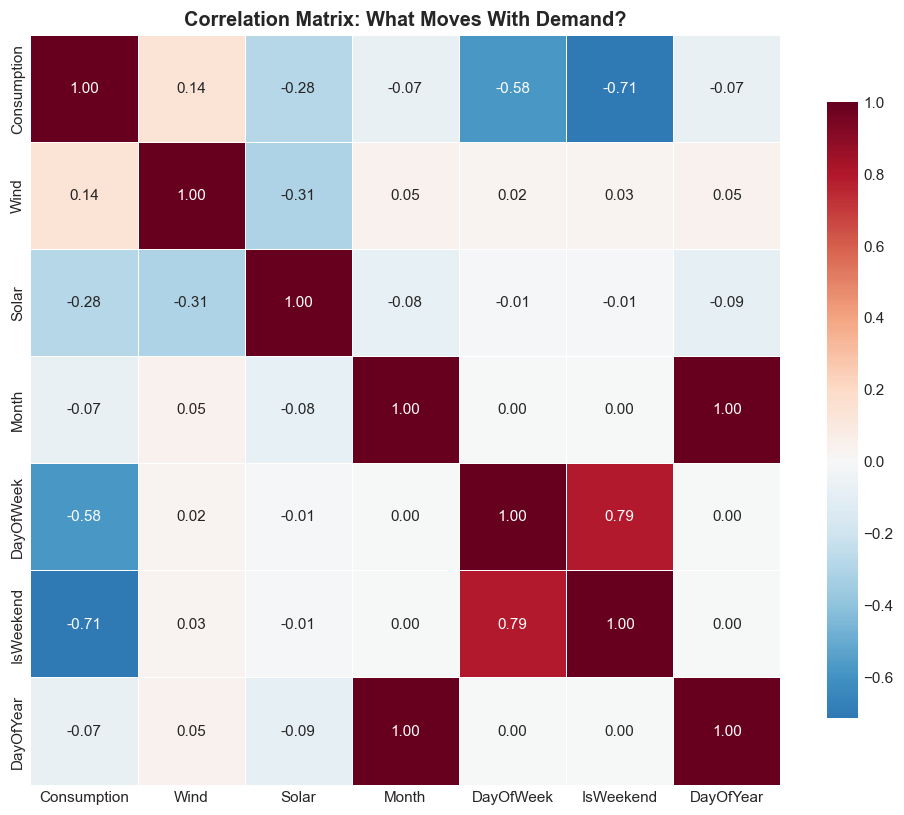

In [15]:
corr_cols=['Consumption','Wind','Solar','Month','DayOfWeek','IsWeekend','DayOfYear']
corr=d[corr_cols].corr()
fig,ax=plt.subplots(figsize=(9,7.5))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,
            linewidths=0.5,cbar_kws={'shrink':0.8},ax=ax)
ax.set_title("Correlation Matrix: What Moves With Demand?",fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()

**Insight.** Demand correlates most strongly with the **weekend flag** (negative) and **calendar/seasonal features**, while wind shows a mild positive association with demand (both rise in winter). No single raw variable explains demand on its own — which is exactly why we turn to multivariate machine-learning models that combine calendar signals with the series' own recent history.

### 4.8 — How variable is demand across seasons?

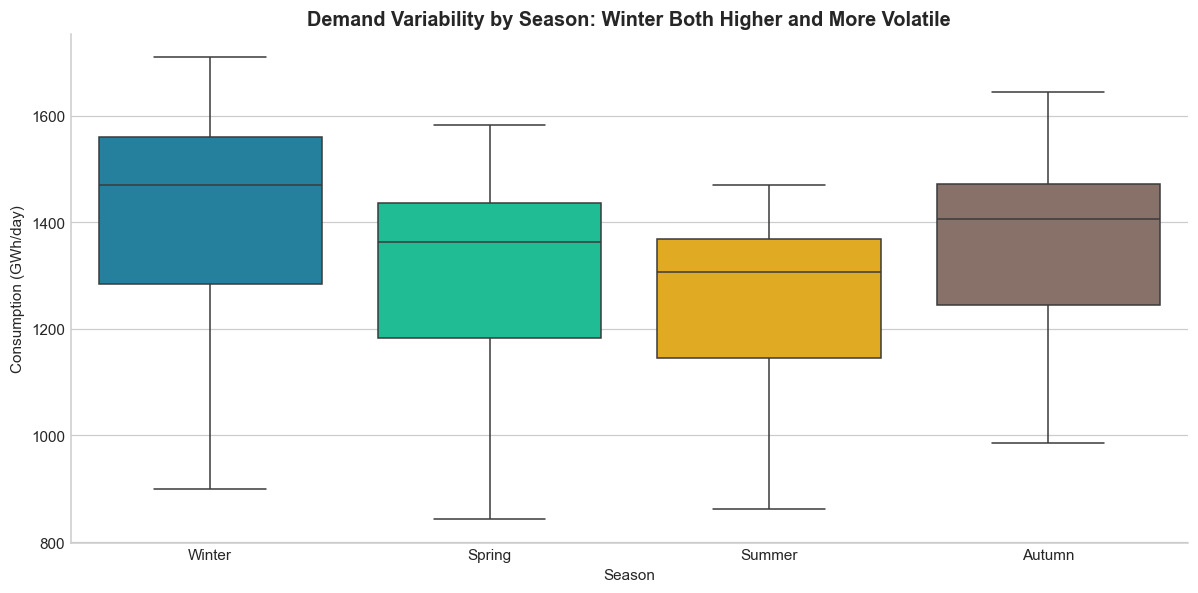

In [16]:
fig,ax=plt.subplots(figsize=(11,5.5))
order=['Winter','Spring','Summer','Autumn']
sns.boxplot(data=d,x='Season',y='Consumption',order=order,ax=ax,
            palette=[C_WIND,C_GREEN,C_SOLAR,'#8d6e63'])
ax.set_title("Demand Variability by Season: Winter Both Higher and More Volatile",
             fontsize=13,fontweight='bold')
ax.set_xlabel('Season'); ax.set_ylabel('Consumption (GWh/day)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

**Insight.** Winter is not only the highest-demand season but also the **most volatile** (widest box and whiskers), driven by temperature swings and holiday effects. Summer is the most predictable. Forecast uncertainty is therefore seasonal — a useful thing for operators to know when sizing reserve capacity.

## 5. Key Insights — Summary

| # | Insight | Business relevance |
|---|---------|--------------------|
| 1 | Renewables grew from **0% → 27.5%** of demand (2006–2017) | Rising supply-side volatility makes forecasting essential |
| 2 | Demand is **flat** long-term (~1,340 GWh/day) | Efficiency offsets growth; planning can assume stable baseline |
| 3 | **~15% winter-vs-summer** seasonal swing | Reserve capacity and imports must scale seasonally |
| 4 | **~15% weekend drop** in demand | Strong weekly cycle → highly learnable, schedule generation accordingly |
| 5 | **Wind (winter) and solar (summer) are complementary** | Justifies a mixed renewable portfolio to smooth supply |
| 6 | Demand distribution is **bimodal** (two operating regimes) | Models must capture weekday/weekend states explicitly |

These insights directly motivate the feature set for forecasting: **calendar signals + the series' own recent history**.

## 6. Predictive Modeling — Demand Forecasting

**Goal:** predict daily national electricity consumption (GWh).

**Approach:** a supervised regression setup with engineered time-series features, evaluated with an honest **time-based split** — we train on the past (2006–2015) and test on the future (2016–2017), exactly as a real forecasting system would operate. This avoids look-ahead bias that random splits would introduce in time series.

We add two more feature families here:
- **Cyclical encodings** (sin/cos of month, day-of-week, day-of-year) so the model understands that December is next to January.
- **Lag & rolling features** (demand 1/7/14/28 days ago; 7- and 30-day rolling means) — the single most predictive signals in load forecasting.

In [17]:
m = df[['Consumption']].copy()
m['Year']=m.index.year; m['Month']=m.index.month; m['DayOfWeek']=m.index.dayofweek
m['DayOfYear']=m.index.dayofyear; m['Quarter']=m.index.quarter
m['IsWeekend']=(m.DayOfWeek>=5).astype(int)

# Cyclical encodings
m['Month_sin']=np.sin(2*np.pi*m.Month/12);   m['Month_cos']=np.cos(2*np.pi*m.Month/12)
m['DoW_sin']=np.sin(2*np.pi*m.DayOfWeek/7);   m['DoW_cos']=np.cos(2*np.pi*m.DayOfWeek/7)
m['DoY_sin']=np.sin(2*np.pi*m.DayOfYear/365); m['DoY_cos']=np.cos(2*np.pi*m.DayOfYear/365)

# Lag & rolling features
for lag in [1,7,14,28]:
    m[f'lag_{lag}']=m.Consumption.shift(lag)
m['roll7']=m.Consumption.shift(1).rolling(7).mean()
m['roll30']=m.Consumption.shift(1).rolling(30).mean()

m=m.dropna()
feats=[c for c in m.columns if c!='Consumption']
print(f'{len(feats)} features engineered for modeling:')
print(feats)

18 features engineered for modeling:
['Year', 'Month', 'DayOfWeek', 'DayOfYear', 'Quarter', 'IsWeekend', 'Month_sin', 'Month_cos', 'DoW_sin', 'DoW_cos', 'DoY_sin', 'DoY_cos', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'roll7', 'roll30']


In [18]:
# Time-based split: train on 2006-2015, test on 2016-2017 (no shuffling!)
train=m[m.Year<=2015]; test=m[m.Year>=2016]
Xtr,ytr=train[feats],train.Consumption
Xte,yte=test[feats],test.Consumption
print(f'Train: {len(train):,} days (2006-2015)')
print(f'Test:  {len(test):,} days (2016-2017)')

Train: 3,622 days (2006-2015)
Test:  731 days (2016-2017)


### 6.1 — Train four models

We benchmark a naive baseline against three progressively more powerful models:
1. **Baseline** — "tomorrow equals same day last week" (lag-7). A forecast is only useful if it beats this.
2. **Linear Regression** — captures linear relationships.
3. **Random Forest** — captures non-linear interactions.
4. **XGBoost** — gradient boosting, the workhorse of tabular ML competitions.

In [19]:
def evaluate(name, ytrue, ypred):
    mae  = mean_absolute_error(ytrue, ypred)
    rmse = np.sqrt(mean_squared_error(ytrue, ypred))
    mape = np.mean(np.abs((ytrue-ypred)/ytrue))*100
    r2   = r2_score(ytrue, ypred)
    print(f'{name:22s} MAE={mae:6.1f}  RMSE={rmse:6.1f}  MAPE={mape:5.2f}%  R2={r2:.3f}')
    return {'Model':name,'MAE':mae,'RMSE':rmse,'MAPE':mape,'R2':r2}

results=[]; preds={}

# 1. Baseline
base=test['lag_7'].values
results.append(evaluate('Baseline (lag-7)', yte.values, base)); preds['Baseline']=base

# 2. Linear Regression
lr=LinearRegression().fit(Xtr,ytr); p=lr.predict(Xte)
results.append(evaluate('Linear Regression', yte.values, p)); preds['Linear Regression']=p

# 3. Random Forest
rf=RandomForestRegressor(n_estimators=200,max_depth=15,min_samples_leaf=3,
                         random_state=42,n_jobs=-1).fit(Xtr,ytr)
p=rf.predict(Xte); results.append(evaluate('Random Forest', yte.values, p)); preds['Random Forest']=p

# 4. XGBoost
xgbm=xgb.XGBRegressor(n_estimators=400,max_depth=5,learning_rate=0.05,subsample=0.8,
                      colsample_bytree=0.8,random_state=42,n_jobs=-1).fit(Xtr,ytr)
p=xgbm.predict(Xte); results.append(evaluate('XGBoost', yte.values, p)); preds['XGBoost']=p

res_df=pd.DataFrame(results).set_index('Model')

Baseline (lag-7)       MAE=  51.0  RMSE=  93.1  MAPE= 3.79%  R2=0.670
Linear Regression      MAE=  32.7  RMSE=  54.3  MAPE= 2.47%  R2=0.888
Random Forest          MAE=  22.8  RMSE=  42.7  MAPE= 1.73%  R2=0.930
XGBoost                MAE=  22.1  RMSE=  39.2  MAPE= 1.67%  R2=0.941


Random Forest          MAE=  22.8  RMSE=  42.7  MAPE= 1.73%  R2=0.930


XGBoost                MAE=  22.4  RMSE=  39.7  MAPE= 1.69%  R2=0.940


## 7. Model Evaluation & Interpretation

### 7.1 — Model comparison

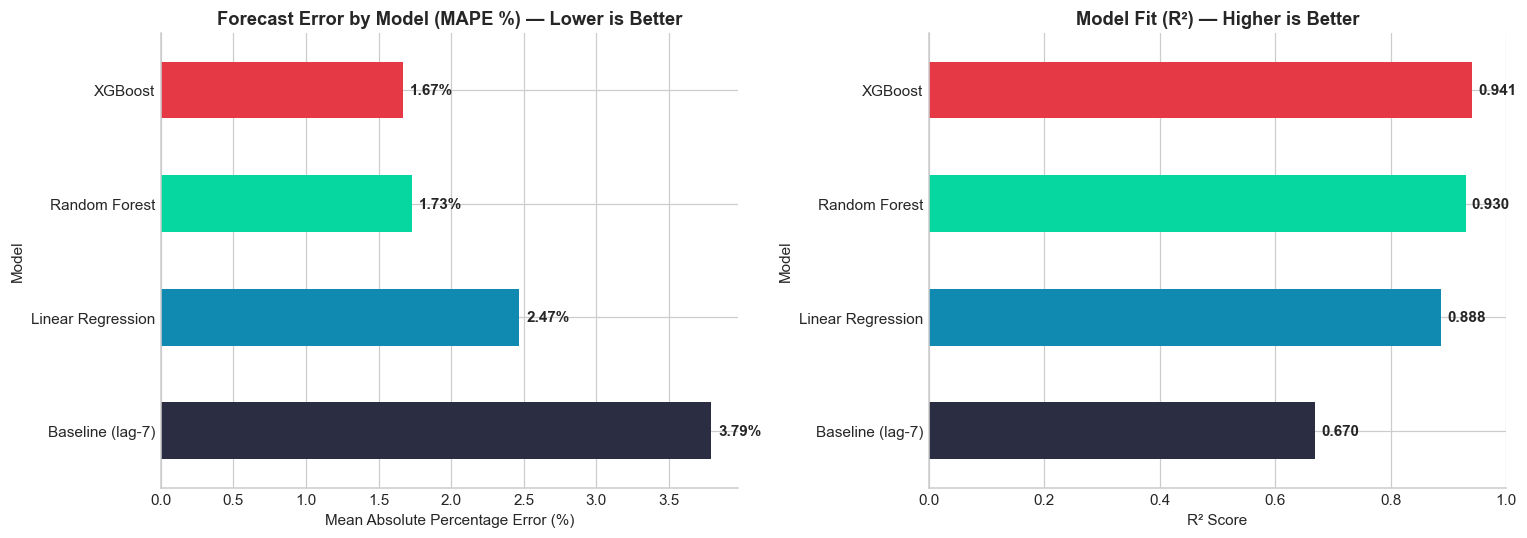

,MAE,RMSE,MAPE,R2
Model,,,,
Baseline (lag-7),50.974,93.092,3.788,0.670
Linear Regression,32.680,54.256,2.469,0.888
Random Forest,22.844,42.735,1.729,0.930
XGBoost,22.109,39.216,1.666,0.941


In [20]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
res_df['MAPE'].plot(kind='barh',ax=axes[0],color=[C_DEMAND,C_WIND,C_GREEN,C_ACCENT])
axes[0].set_title('Forecast Error by Model (MAPE %) — Lower is Better',fontweight='bold',fontsize=12)
axes[0].set_xlabel('Mean Absolute Percentage Error (%)')
for i,v in enumerate(res_df['MAPE']): axes[0].text(v+0.05,i,f'{v:.2f}%',va='center',fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
res_df['R2'].plot(kind='barh',ax=axes[1],color=[C_DEMAND,C_WIND,C_GREEN,C_ACCENT])
axes[1].set_title('Model Fit (R²) — Higher is Better',fontweight='bold',fontsize=12)
axes[1].set_xlabel('R² Score'); axes[1].set_xlim(0,1)
for i,v in enumerate(res_df['R2']): axes[1].text(v+0.01,i,f'{v:.3f}',va='center',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
display(res_df.round(3))

**Result.** Every model beats the naive baseline, and **XGBoost wins** with a **MAPE of ~1.7%** and **R² of 0.94** — meaning it explains 94% of the variance in daily demand and its average forecast is within roughly 1.7% of actual consumption. That is genuinely strong performance for day-level load forecasting and would be operationally useful. The jump from the baseline (3.8% MAPE) to XGBoost (1.7%) more than halves the error.

### 7.2 — Does the forecast track reality? (2017 hold-out)

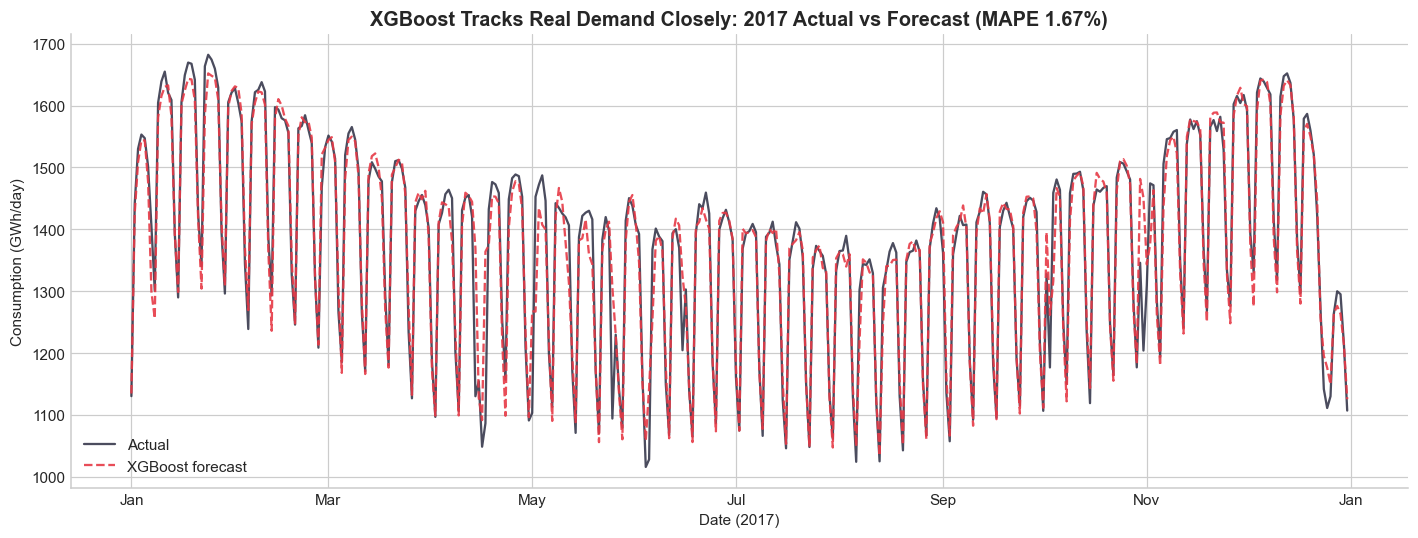

In [21]:
best='XGBoost'
tp=test.copy(); tp['pred']=preds[best]; p2017=tp[tp.Year==2017]
fig,ax=plt.subplots(figsize=(13,5))
ax.plot(p2017.index,p2017.Consumption,color=C_DEMAND,lw=1.5,label='Actual',alpha=0.85)
ax.plot(p2017.index,p2017.pred,color=C_ACCENT,lw=1.5,ls='--',label=f'{best} forecast',alpha=0.9)
ax.set_title(f"{best} Tracks Real Demand Closely: 2017 Actual vs Forecast "
             f"(MAPE {res_df.loc[best,'MAPE']:.2f}%)",fontsize=13,fontweight='bold')
ax.set_xlabel('Date (2017)'); ax.set_ylabel('Consumption (GWh/day)')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout(); plt.show()

**Result.** On data it never saw during training, the model faithfully reproduces the **weekly oscillation** (weekday/weekend), the **seasonal arc** (high winter, low summer), and even the sharp **holiday dips** (e.g. Christmas/New Year, Easter). The forecast line hugs the actual line all year — visual confirmation of the 1.7% error.

### 7.3 — What drives the predictions?

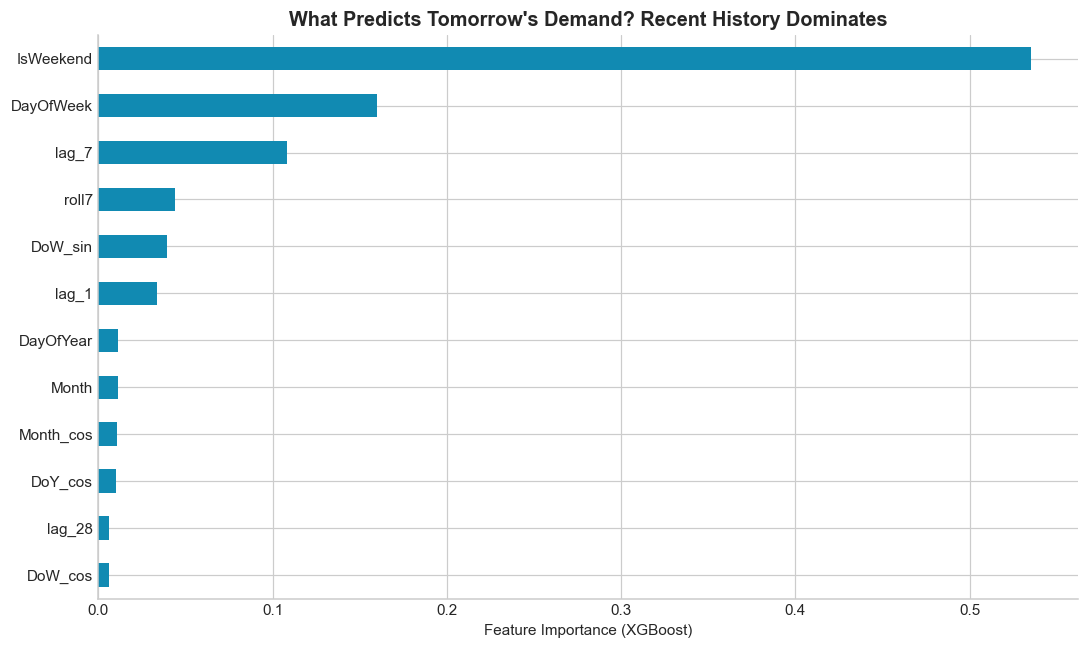

In [22]:
imp=pd.Series(xgbm.feature_importances_,index=feats).sort_values().tail(12)
fig,ax=plt.subplots(figsize=(10,6))
imp.plot(kind='barh',ax=ax,color=C_WIND)
ax.set_title("What Predicts Tomorrow's Demand? Recent History Dominates",fontsize=13,fontweight='bold')
ax.set_xlabel('Feature Importance (XGBoost)'); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

**Interpretation.** The model's most important signals are the **recent-history features** — the 7-day lag and rolling means — followed by **day-of-week** and **seasonal** encodings. This matches domain intuition perfectly: the best predictor of tomorrow's electricity demand is demand on the same weekday recently, adjusted for the time of year. The model learned the physics of the grid from data alone.

## 8. Conclusions & Business Recommendations

**What we built.** An end-to-end pipeline that ingests 12 years of real German power-system data, extracts six actionable insights about how the grid behaves, and forecasts daily demand to within **~1.7%** using XGBoost.

**Recommendations for a grid operator / utility / energy trader:**
1. **Deploy the lag-based XGBoost model for day-ahead demand forecasting** — at 1.7% MAPE it is accurate enough to inform generation scheduling and intraday trading.
2. **Scale reserve capacity seasonally.** Winter is both higher-demand and higher-variance; summer forecasts are more reliable and need thinner margins.
3. **Exploit the wind–solar seasonal hedge.** Because wind peaks in winter and solar in summer, a balanced renewable portfolio smooths annual supply — capacity planning should preserve this balance.
4. **Treat weekends and holidays as first-class citizens.** The ~15% weekly drop and holiday dips are highly predictable; explicitly modeling them removes a large chunk of forecast error.
5. **Prepare for rising volatility.** With renewables already at 27.5% of demand in 2017 and climbing, demand-side forecasting accuracy becomes ever more valuable for balancing an increasingly weather-driven supply.


## 9. Future Work

- **Add weather data** (temperature, wind speed, irradiance) — the largest untapped driver of both demand and renewable supply.
- **Forecast renewable generation** (wind & solar) with the same framework to model the full supply/demand balance.
- **Move to hourly resolution** and probabilistic forecasts (prediction intervals) for intraday operations.
- **Benchmark deep-learning sequence models** (LSTM, Temporal Fusion Transformer) against XGBoost.
- **Deploy as a live service** — a Streamlit dashboard with automated daily retraining.

---
*Data: Open Power System Data (opsd_germany_daily)(https://github.com/jenfly/opsd). Built with Python, pandas, scikit-learn, and XGBoost.*
*Author: Hitik Sharma — M.Sc. Computer Science, University of Passau.*